In [21]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 172.7 kB/s eta 0:00:0000:0100:04


In [11]:
import pandas as pd
import numpy as np

In [12]:
df = pd.read_csv('../data/Final Data/Chl-a/Chl-a-7-day.csv')

In [13]:
df['Chl-a'] = np.log1p(df['Chl-a'])

In [14]:
Q1 = df['Chl-a'].quantile(0.25)
Q3 = df['Chl-a'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Chl-a'] >= lower_bound) & (df['Chl-a'] <= upper_bound)]

In [15]:
df['NDVI'] = (df['B8'] - df['B4']) / (df['B8'] + df['B4'])

In [16]:
X = df.drop(columns=['Chl-a'])
y = df['Chl-a']

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
input_features = X_train.shape[1]
input_features

11

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor
import numpy as np

# Define models and hyperparameter grids
models = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=1),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    },
    "SVM": {
        "model": SVR(),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    "CatBoost": {
        "model": CatBoostRegressor(verbose=0, random_state=1),
        "params": {
            "iterations": [100, 200],
            "depth": [4, 6, 8],
            "learning_rate": [0.01, 0.1, 0.2]
        }
    },
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    }
}

# Perform GridSearchCV and evaluate models
results = {}
for name, model_info in models.items():
    print(f"Training {name}...")
    grid = GridSearchCV(model_info["model"], model_info["params"], cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {"R2 Score": r2, "RMSE": rmse}
    print(f"{name} - Best Params: {grid.best_params_}")

# Print results
print("\nModel Performance:")
for model_name, metrics in results.items():
    print(f"{model_name}: R2 Score = {metrics['R2 Score']:.4f}, RMSE = {metrics['RMSE']:.4f}")

Training Random Forest...
Random Forest - Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Training SVM...
SVM - Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Training CatBoost...
CatBoost - Best Params: {'depth': 8, 'iterations': 100, 'learning_rate': 0.1}
Training Linear Regression...
Linear Regression - Best Params: {}

Model Performance:
Random Forest: R2 Score = 0.6766, RMSE = 0.1242
SVM: R2 Score = 0.6506, RMSE = 0.1291
CatBoost: R2 Score = 0.6848, RMSE = 0.1226
Linear Regression: R2 Score = 0.3296, RMSE = 0.1788


In [23]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Update models with additional algorithms and expanded hyperparameter grids
models.update({
    "XGBoost": {
        "model": XGBRegressor(random_state=1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "subsample": [0.8, 1.0]
        }
    },
    "LightGBM": {
        "model": LGBMRegressor(random_state=1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [-1, 10, 20],
            "learning_rate": [0.01, 0.1, 0.2],
            "num_leaves": [31, 50, 100]
        }
    }
})

# Perform GridSearchCV and evaluate models
results = {}
for name, model_info in models.items():
    print(f"Training {name}...")
    grid = GridSearchCV(model_info["model"], model_info["params"], cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {"R2 Score": r2, "RMSE": rmse}
    print(f"{name} - Best Params: {grid.best_params_}")

# Print results
print("\nEnhanced Model Performance:")
for model_name, metrics in results.items():
    print(f"{model_name}: R2 Score = {metrics['R2 Score']:.4f}, RMSE = {metrics['RMSE']:.4f}")

Training Random Forest...
Random Forest - Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Training SVM...
SVM - Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Training CatBoost...
CatBoost - Best Params: {'depth': 8, 'iterations': 100, 'learning_rate': 0.1}
Training Linear Regression...
Linear Regression - Best Params: {}
Training XGBoost...
XGBoost - Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004459 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 2194, number of used features: 11
[LightGBM] [Info] Start training from score 1.119152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002515 seconds.
You can set `force_col_wise=true` to remove the over

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Function to build and train the model
def build_and_evaluate_model(use_batch_norm=False, use_leaky_relu=False, use_dropout=False):
    model = Sequential()
    model.add(Dense(64, input_dim=input_features))
    
    if use_batch_norm:
        model.add(BatchNormalization())
    if use_leaky_relu:
        model.add(LeakyReLU(alpha=0.1))
    else:
        model.add(tf.keras.layers.ReLU())
    if use_dropout:
        model.add(Dropout(0.3))
    
    model.add(Dense(32))
    if use_batch_norm:
        model.add(BatchNormalization())
    if use_leaky_relu:
        model.add(LeakyReLU(alpha=0.1))
    else:
        model.add(tf.keras.layers.ReLU())
    if use_dropout:
        model.add(Dropout(0.3))
    
    model.add(Dense(1))  # Output layer
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    
    y_pred = model.predict(X_test).flatten()
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return r2, rmse

# Evaluate models with different configurations
configurations = [
    {"use_batch_norm": False, "use_leaky_relu": False, "use_dropout": False},
    {"use_batch_norm": True, "use_leaky_relu": False, "use_dropout": False},
    {"use_batch_norm": False, "use_leaky_relu": True, "use_dropout": False},
    {"use_batch_norm": False, "use_leaky_relu": False, "use_dropout": True},
    {"use_batch_norm": True, "use_leaky_relu": True, "use_dropout": True},
]

results_ann = {}
for config in configurations:
    print(f"Evaluating configuration: {config}")
    r2, rmse = build_and_evaluate_model(**config)
    results_ann[str(config)] = {"R2 Score": r2, "RMSE": rmse}
    print(f"R2 Score: {r2:.4f}, RMSE: {rmse:.4f}")

# Print results
print("\nANN Model Performance:")
for config, metrics in results_ann.items():
    print(f"{config}: R2 Score = {metrics['R2 Score']:.4f}, RMSE = {metrics['RMSE']:.4f}")

Evaluating configuration: {'use_batch_norm': False, 'use_leaky_relu': False, 'use_dropout': False}


/Users/kavyasmac/anaconda3/envs/new_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step
R2 Score: 0.6810, RMSE: 0.1233
Evaluating configuration: {'use_batch_norm': True, 'use_leaky_relu': False, 'use_dropout': False}


/Users/kavyasmac/anaconda3/envs/new_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R2 Score: 0.5519, RMSE: 0.1462
Evaluating configuration: {'use_batch_norm': False, 'use_leaky_relu': True, 'use_dropout': False}


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step
R2 Score: 0.6355, RMSE: 0.1318
Evaluating configuration: {'use_batch_norm': False, 'use_leaky_relu': False, 'use_dropout': True}


/Users/kavyasmac/anaconda3/envs/new_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step
R2 Score: 0.6538, RMSE: 0.1285
Evaluating configuration: {'use_batch_norm': True, 'use_leaky_relu': True, 'use_dropout': True}


/Users/kavyasmac/anaconda3/envs/new_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/kavyasmac/anaconda3/envs/new_env/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R2 Score: 0.5923, RMSE: 0.1394

ANN Model Performance:
{'use_batch_norm': False, 'use_leaky_relu': False, 'use_dropout': False}: R2 Score = 0.6810, RMSE = 0.1233
{'use_batch_norm': True, 'use_leaky_relu': False, 'use_dropout': False}: R2 Score = 0.5519, RMSE = 0.1462
{'use_batch_norm': False, 'use_leaky_relu': True, 'use_dropout': False}: R2 Score = 0.6355, RMSE = 0.1318
{'use_batch_norm': False, 'use_leaky_relu': False, 'use_dropout': True}: R2 Score = 0.6538, RMSE = 0.1285
{'use_batch_norm': True, 'use_leaky_relu': True, 'use_dropout': True}: R2 Score = 0.5923, RMSE = 0.1394


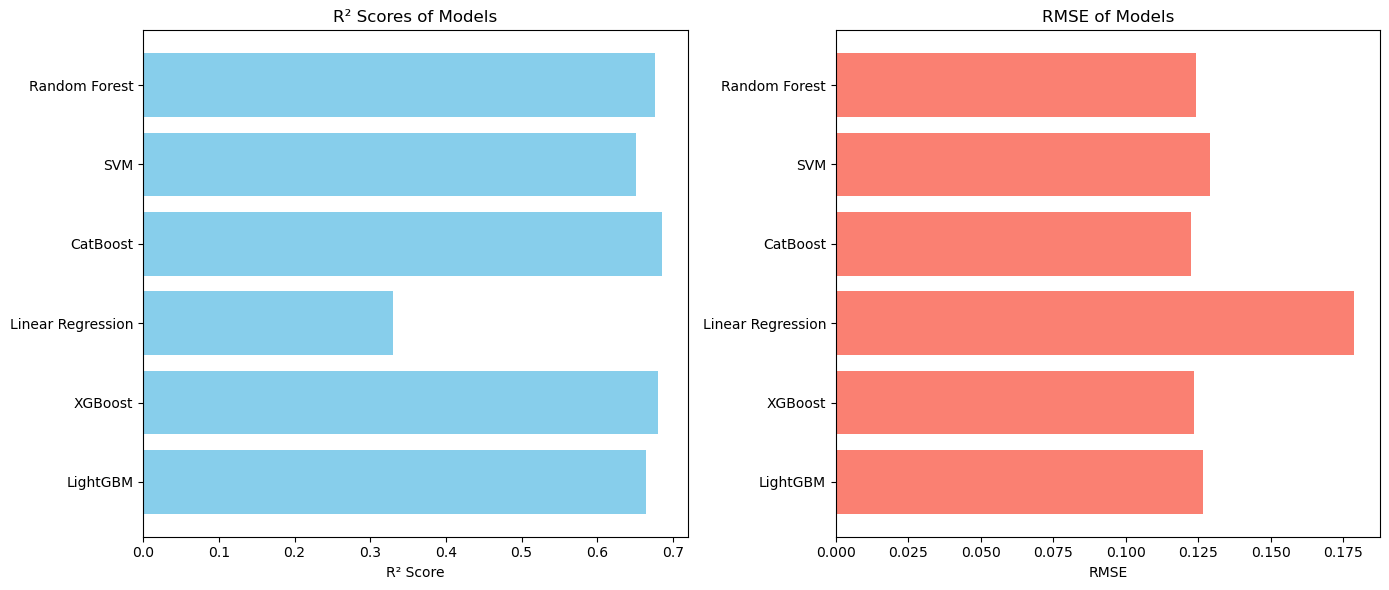

In [25]:
import matplotlib.pyplot as plt

# Extract model names, R2 scores, and RMSE values
model_names = list(results.keys())
r2_scores = [metrics["R2 Score"] for metrics in results.values()]
rmse_values = [metrics["RMSE"] for metrics in results.values()]

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot for R2 scores
ax[0].barh(model_names, r2_scores, color='skyblue')
ax[0].set_xlabel('R² Score')
ax[0].set_title('R² Scores of Models')
ax[0].invert_yaxis()

# Bar plot for RMSE values
ax[1].barh(model_names, rmse_values, color='salmon')
ax[1].set_xlabel('RMSE')
ax[1].set_title('RMSE of Models')
ax[1].invert_yaxis()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()